# ST456 Deep Learning - PCam Histopathology Classification


## Section 0 - Setup chunks

In [1]:
# Mount Drive and clone repo
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
!git clone https://github.com/migathicharian/ST456_GroupProject.git /content/ST456_GroupProject
!pip install timm -q
import sys
sys.path.insert(0, '/content/ST456_GroupProject/code')

Mounted at /content/drive
Cloning into '/content/ST456_GroupProject'...
remote: Enumerating objects: 169, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 169 (delta 11), reused 22 (delta 6), pack-reused 134 (from 1)
Receiving objects: 100% (169/169), 164.04 MiB | 35.32 MiB/s, done.
Resolving deltas: 100% (85/85), done.


In [2]:
from pathlib import Path

# Paths - edit this to your Drive folder location
DRIVE_DATA_DIR = Path('/content/drive/MyDrive/ST456 Group project/pcamv1')
DATA_DIR = Path('/content/pcam_data')
CHECKPOINT_DIR = Path('/content/ST456_GroupProject/checkpoints')
RESULTS_DIR = Path('/content/ST456_GroupProject/results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Checkpoints: {CHECKPOINT_DIR}")
print(f"Results:     {RESULTS_DIR}")

Checkpoints: /content/ST456_GroupProject/checkpoints
Results:     /content/ST456_GroupProject/results


In [3]:
from data import load_all_data, build_downstream_loaders, LABEL_FRACTIONS

print("Loading PCam data...")
data = load_all_data(
    drive_data_dir=DRIVE_DATA_DIR,
    data_dir=DATA_DIR,
    pretrain_fraction=0.15,
    downstream_pool_fraction=0.15,
    use_subset=True,
)

train_loaders, val_loader, test_loader = build_downstream_loaders(data)
print("\nLabel fractions:", list(LABEL_FRACTIONS.keys()))
print("Train loaders:", {k: len(v.dataset) for k, v in train_loaders.items()})

Loading PCam data...

Label fractions: ['1%', '5%', '10%']
Train loaders: {'1%': 393, '5%': 1966, '10%': 3932}


## Section 1 - Pre-training SSL Encoders

In [4]:
from training import train_simclr, SEED

# Improve SimCLR tailored - 50 epochs, AdamW + cosine schedule + warmup
simclr_model, simclr_history, simclr_ckpt = train_simclr(
    data=data,
    checkpoint_dir=CHECKPOINT_DIR,
    epochs=50,
    batch_size=128,
    learning_rate=3e-4,
    warmup_epochs=2,
    weight_decay=0.05,
    tailored=True,
    checkpoint_name='simclr_encoder_tailored.pth',
)
print(f"\nSimCLR (tailored) checkpoint saved -> {simclr_ckpt}")

SimCLR epoch 1/50 - loss: 4.2726 - lr: 0.000150
SimCLR epoch 2/50 - loss: 3.8994 - lr: 0.000300
SimCLR epoch 3/50 - loss: 3.8341 - lr: 0.000300
SimCLR epoch 4/50 - loss: 3.7982 - lr: 0.000299
SimCLR epoch 5/50 - loss: 3.7804 - lr: 0.000297
SimCLR epoch 6/50 - loss: 3.7683 - lr: 0.000295
SimCLR epoch 7/50 - loss: 3.7547 - lr: 0.000292
SimCLR epoch 8/50 - loss: 3.7467 - lr: 0.000289
SimCLR epoch 9/50 - loss: 3.7424 - lr: 0.000285
SimCLR epoch 10/50 - loss: 3.7355 - lr: 0.000280
SimCLR epoch 11/50 - loss: 3.7277 - lr: 0.000275
SimCLR epoch 12/50 - loss: 3.7228 - lr: 0.000269
SimCLR epoch 13/50 - loss: 3.7188 - lr: 0.000263
SimCLR epoch 14/50 - loss: 3.7143 - lr: 0.000256
SimCLR epoch 15/50 - loss: 3.7109 - lr: 0.000249
SimCLR epoch 16/50 - loss: 3.7082 - lr: 0.000241
SimCLR epoch 17/50 - loss: 3.7039 - lr: 0.000233
SimCLR epoch 18/50 - loss: 3.7004 - lr: 0.000225
SimCLR epoch 19/50 - loss: 3.6982 - lr: 0.000216
SimCLR epoch 20/50 - loss: 3.6944 - lr: 0.000207
SimCLR epoch 21/50 - loss: 3.

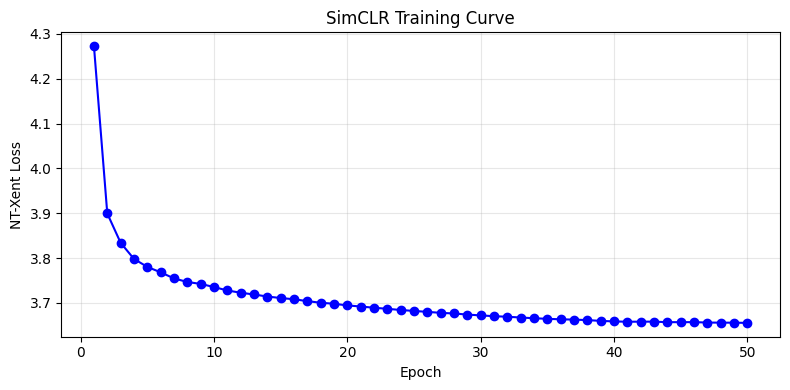

In [5]:
# Plot SimCLR training loss
import pandas as pd, matplotlib.pyplot as plt

df = pd.DataFrame(simclr_history)
plt.figure(figsize=(8, 4))
plt.plot(df['epoch'], df['loss'], 'b-o')
plt.xlabel('Epoch'); plt.ylabel('NT-Xent Loss')
plt.title('SimCLR Training Curve')
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

In [6]:
# SimCLR GENERIC augmentation (ablation vs tailored)
simclr_model_generic, simclr_history_generic, simclr_ckpt_generic = train_simclr(
    data=data,
    checkpoint_dir=CHECKPOINT_DIR,
    epochs=50,
    batch_size=128,
    learning_rate=3e-4,
    warmup_epochs=2,
    weight_decay=0.05,
    tailored=False,                     # tailored to ablation
    checkpoint_name='simclr_encoder_generic.pth',
)
print(f"\nSimCLR (generic) checkpoint saved -> {simclr_ckpt_generic}")

SimCLR epoch 1/50 - loss: 4.5628 - lr: 0.000150
SimCLR epoch 2/50 - loss: 4.2201 - lr: 0.000300
SimCLR epoch 3/50 - loss: 4.1259 - lr: 0.000300
SimCLR epoch 4/50 - loss: 4.0744 - lr: 0.000299
SimCLR epoch 5/50 - loss: 4.0388 - lr: 0.000297
SimCLR epoch 6/50 - loss: 4.0091 - lr: 0.000295
SimCLR epoch 7/50 - loss: 3.9914 - lr: 0.000292
SimCLR epoch 8/50 - loss: 3.9751 - lr: 0.000289
SimCLR epoch 9/50 - loss: 3.9638 - lr: 0.000285
SimCLR epoch 10/50 - loss: 3.9527 - lr: 0.000280
SimCLR epoch 11/50 - loss: 3.9421 - lr: 0.000275
SimCLR epoch 12/50 - loss: 3.9336 - lr: 0.000269
SimCLR epoch 13/50 - loss: 3.9255 - lr: 0.000263
SimCLR epoch 14/50 - loss: 3.9164 - lr: 0.000256
SimCLR epoch 15/50 - loss: 3.9142 - lr: 0.000249
SimCLR epoch 16/50 - loss: 3.9069 - lr: 0.000241
SimCLR epoch 17/50 - loss: 3.8983 - lr: 0.000233
SimCLR epoch 18/50 - loss: 3.8919 - lr: 0.000225
SimCLR epoch 19/50 - loss: 3.8881 - lr: 0.000216
SimCLR epoch 20/50 - loss: 3.8833 - lr: 0.000207
SimCLR epoch 21/50 - loss: 3.

In [7]:
from training import train_mae

# MAE Improve — 50 epochs, lr=1.5e-4 (MAE paper's linear scaling), cosine + warmup
mae_model, mae_history, mae_ckpt = train_mae(
    data=data,
    checkpoint_dir=CHECKPOINT_DIR,
    epochs=50,
    batch_size=128,
    learning_rate=1.5e-4,
    warmup_epochs=2,
    weight_decay=0.05,
    checkpoint_name='mae_encoder.pth',
)
print(f"\nMAE checkpoint saved -> {mae_ckpt}")

MAE epoch 1/50 - loss: 4.3096 - lr: 0.000075
MAE epoch 2/50 - loss: 0.8216 - lr: 0.000150
MAE epoch 3/50 - loss: 0.7969 - lr: 0.000150
MAE epoch 4/50 - loss: 0.7920 - lr: 0.000149
MAE epoch 5/50 - loss: 0.7904 - lr: 0.000149
MAE epoch 6/50 - loss: 0.7902 - lr: 0.000147
MAE epoch 7/50 - loss: 0.7899 - lr: 0.000146
MAE epoch 8/50 - loss: 0.7897 - lr: 0.000144
MAE epoch 9/50 - loss: 0.7898 - lr: 0.000142
MAE epoch 10/50 - loss: 0.7883 - lr: 0.000140
MAE epoch 11/50 - loss: 0.7690 - lr: 0.000137
MAE epoch 12/50 - loss: 0.7337 - lr: 0.000135
MAE epoch 13/50 - loss: 0.7271 - lr: 0.000131
MAE epoch 14/50 - loss: 0.7245 - lr: 0.000128
MAE epoch 15/50 - loss: 0.7226 - lr: 0.000124
MAE epoch 16/50 - loss: 0.7204 - lr: 0.000121
MAE epoch 17/50 - loss: 0.7197 - lr: 0.000117
MAE epoch 18/50 - loss: 0.7191 - lr: 0.000112
MAE epoch 19/50 - loss: 0.7178 - lr: 0.000108
MAE epoch 20/50 - loss: 0.7171 - lr: 0.000104
MAE epoch 21/50 - loss: 0.7162 - lr: 0.000099
MAE epoch 22/50 - loss: 0.7153 - lr: 0.0000

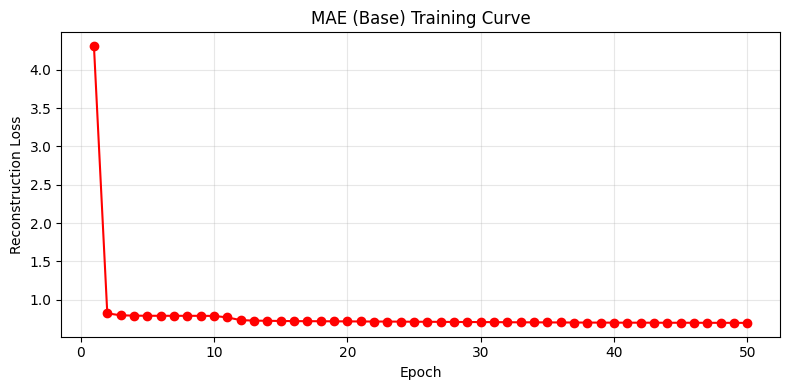

In [8]:
# Plot MAE training loss
df = pd.DataFrame(mae_history)
plt.figure(figsize=(8, 4))
plt.plot(df['epoch'], df['loss'], 'r-o')
plt.xlabel('Epoch'); plt.ylabel('Reconstruction Loss')
plt.title('MAE (Base) Training Curve')
plt.grid(True, alpha=0.3); plt.tight_layout()
plt.show()

In [9]:
import os


print("Pre-training Complete — Checkpoints")

for name, path in [
    ('SimCLR (tailored)',   CHECKPOINT_DIR / 'simclr_encoder_tailored.pth'),
    ('SimCLR (generic)',    CHECKPOINT_DIR / 'simclr_encoder_generic.pth'),
    ('MAE (base)',          CHECKPOINT_DIR / 'mae_encoder.pth'),
]:
    status = 'FOUND' if path.exists() else 'MISSING'
    if path.exists():
        size_mb = os.path.getsize(path) / 1e6
        print(f"  {status}  {name:<22}  {size_mb:.1f} MB  {path}")
    else:
        print(f"  {status}  {name:<22}  (not found)")

Pre-training Complete — Checkpoints
  FOUND  SimCLR (tailored)       44.8 MB  /content/ST456_GroupProject/checkpoints/simclr_encoder_tailored.pth
  FOUND  SimCLR (generic)        44.8 MB  /content/ST456_GroupProject/checkpoints/simclr_encoder_generic.pth
  FOUND  MAE (base)              12.8 MB  /content/ST456_GroupProject/checkpoints/mae_encoder.pth


## Section 2 - Downstream Experiment Grid


In [10]:
# Run Section 0 first so that CHECKPOINT_DIR, RESULTS_DIR,
# data, train_loaders, val_loader, test_loader are all in scope.
import os
from training import (
    run_single_experiment,
    run_experiment_grid,
    TrainConfig,
    DEFAULT_EXPERIMENT_CONFIG,
    MAIN_METHODS,
    FINETUNE_STRATEGIES,
)

# Verify checkpoints produced by Section 1 are present
_ckpts = {
    'simclr_encoder_tailored.pth': CHECKPOINT_DIR / 'simclr_encoder_tailored.pth',
    'simclr_encoder_generic.pth':  CHECKPOINT_DIR / 'simclr_encoder_generic.pth',
    'mae_encoder.pth':             CHECKPOINT_DIR / 'mae_encoder.pth',
}
for _name, _path in _ckpts.items():
    if not _path.exists():
        raise FileNotFoundError(
            f"Checkpoint missing: {_path}\n"
            "Run Section 1 first, or copy the checkpoints into CHECKPOINT_DIR."
        )
    print(f"  checked -  {_name}")
print("All checkpoints found — ready to run experiments.")

  checked -  simclr_encoder_tailored.pth
  checked -  simclr_encoder_generic.pth
  checked -  mae_encoder.pth
All checkpoints found — ready to run experiments.


In [11]:
# Grid A — Seed 42
results_42 = run_experiment_grid(
    methods=MAIN_METHODS,
    strategies=FINETUNE_STRATEGIES,
    label_names=list(LABEL_FRACTIONS.keys()),
    seeds=[42],
    train_loaders=train_loaders,
    val_loader=val_loader,
    test_loader=test_loader,
    simclr_checkpoint=CHECKPOINT_DIR / 'simclr_encoder_tailored.pth',
    mae_checkpoint=CHECKPOINT_DIR / 'mae_encoder.pth',
    config=DEFAULT_EXPERIMENT_CONFIG,
)
results_42.to_csv(RESULTS_DIR / 'results_seed42.csv', index=False)
print(f"Seed 42 done — {len(results_42)} rows -> {RESULTS_DIR / 'results_seed42.csv'}")
display(results_42)

Running supervised_from_scratch | frozen | 1% | seed=42
epoch 1/15 | train_loss=0.7207 | val_auc=0.6448 | val_f1=0.0157
epoch 2/15 | train_loss=0.6643 | val_auc=0.7549 | val_f1=0.1250
epoch 3/15 | train_loss=0.6475 | val_auc=0.7995 | val_f1=0.7228
epoch 4/15 | train_loss=0.6368 | val_auc=0.7844 | val_f1=0.7085
epoch 5/15 | train_loss=0.6060 | val_auc=0.7670 | val_f1=0.6911
epoch 6/15 | train_loss=0.5843 | val_auc=0.7666 | val_f1=0.6856
Early stopping triggered.
Running supervised_from_scratch | frozen | 5% | seed=42
epoch 1/15 | train_loss=0.6439 | val_auc=0.7736 | val_f1=0.6968
epoch 2/15 | train_loss=0.5671 | val_auc=0.7830 | val_f1=0.7078
epoch 3/15 | train_loss=0.5472 | val_auc=0.7974 | val_f1=0.7170
epoch 4/15 | train_loss=0.5392 | val_auc=0.8118 | val_f1=0.7287
epoch 5/15 | train_loss=0.5228 | val_auc=0.7996 | val_f1=0.6980
epoch 6/15 | train_loss=0.5199 | val_auc=0.8090 | val_f1=0.7184
epoch 7/15 | train_loss=0.5196 | val_auc=0.8127 | val_f1=0.7258
epoch 8/15 | train_loss=0.5180

,method,strategy,label_fraction,seed,best_epoch,best_val_auc,test_accuracy,test_f1,test_auc
0,supervised_from_scratch,frozen,1%,42,3,0.799451,0.702209,0.755304,0.825435
1,supervised_from_scratch,frozen,5%,42,15,0.837504,0.760773,0.789427,0.853467
2,supervised_from_scratch,frozen,10%,42,13,0.845640,0.779053,0.787944,0.849123
3,supervised_from_scratch,partial,1%,42,7,0.866815,0.777039,0.767117,0.854463
4,supervised_from_scratch,partial,5%,42,3,0.887393,0.763184,0.793177,0.876267
5,supervised_from_scratch,partial,10%,42,5,0.882583,0.681946,0.750419,0.858618
6,supervised_from_scratch,full,1%,42,7,0.872309,0.598938,0.709659,0.848177
7,supervised_from_scratch,full,5%,42,3,0.898471,0.632233,0.726456,0.879062
8,supervised_from_scratch,full,10%,42,1,0.886869,0.778076,0.805769,0.883231
9,simclr,frozen,1%,42,5,0.875053,0.741699,0.708961,0.849534


In [12]:
# Grid B — Seed 52
results_52 = run_experiment_grid(
    methods=MAIN_METHODS,
    strategies=FINETUNE_STRATEGIES,
    label_names=list(LABEL_FRACTIONS.keys()),
    seeds=[52],
    train_loaders=train_loaders,
    val_loader=val_loader,
    test_loader=test_loader,
    simclr_checkpoint=CHECKPOINT_DIR / 'simclr_encoder_tailored.pth',
    mae_checkpoint=CHECKPOINT_DIR / 'mae_encoder.pth',
    config=DEFAULT_EXPERIMENT_CONFIG,
)
results_52.to_csv(RESULTS_DIR / 'results_seed52.csv', index=False)
print(f"Seed 52 done — {len(results_52)} rows -> {RESULTS_DIR / 'results_seed52.csv'}")
display(results_52)

Running supervised_from_scratch | frozen | 1% | seed=52
epoch 1/15 | train_loss=0.6593 | val_auc=0.7093 | val_f1=0.0106
epoch 2/15 | train_loss=0.6363 | val_auc=0.7409 | val_f1=0.6936
epoch 3/15 | train_loss=0.6426 | val_auc=0.8019 | val_f1=0.7212
epoch 4/15 | train_loss=0.6108 | val_auc=0.8003 | val_f1=0.7261
epoch 5/15 | train_loss=0.6064 | val_auc=0.7887 | val_f1=0.7140
epoch 6/15 | train_loss=0.6109 | val_auc=0.7897 | val_f1=0.7175
Early stopping triggered.
Running supervised_from_scratch | frozen | 5% | seed=52
epoch 1/15 | train_loss=0.6338 | val_auc=0.7792 | val_f1=0.7104
epoch 2/15 | train_loss=0.5665 | val_auc=0.7712 | val_f1=0.6980
epoch 3/15 | train_loss=0.5445 | val_auc=0.7950 | val_f1=0.7227
epoch 4/15 | train_loss=0.5322 | val_auc=0.8071 | val_f1=0.7315
epoch 5/15 | train_loss=0.5211 | val_auc=0.8092 | val_f1=0.7347
epoch 6/15 | train_loss=0.5157 | val_auc=0.8134 | val_f1=0.7365
epoch 7/15 | train_loss=0.5165 | val_auc=0.8143 | val_f1=0.7366
epoch 8/15 | train_loss=0.5104

,method,strategy,label_fraction,seed,best_epoch,best_val_auc,test_accuracy,test_f1,test_auc
0,supervised_from_scratch,frozen,1%,52,3,0.801871,0.740631,0.761686,0.817189
1,supervised_from_scratch,frozen,5%,52,10,0.824000,0.743073,0.750925,0.819105
2,supervised_from_scratch,frozen,10%,52,12,0.836439,0.739685,0.741249,0.815932
3,supervised_from_scratch,partial,1%,52,4,0.855827,0.760529,0.747368,0.835804
4,supervised_from_scratch,partial,5%,52,2,0.882015,0.722107,0.764727,0.842760
5,supervised_from_scratch,partial,10%,52,2,0.883687,0.687592,0.743157,0.831264
6,supervised_from_scratch,full,1%,52,8,0.844832,0.750763,0.753181,0.817143
7,supervised_from_scratch,full,5%,52,2,0.877971,0.758636,0.726588,0.844003
8,supervised_from_scratch,full,10%,52,2,0.883734,0.713898,0.759843,0.849985
9,simclr,frozen,1%,52,3,0.876615,0.753754,0.751011,0.838036


In [13]:
# Grid C — Seed 62
results_62 = run_experiment_grid(
    methods=MAIN_METHODS,
    strategies=FINETUNE_STRATEGIES,
    label_names=list(LABEL_FRACTIONS.keys()),
    seeds=[62],
    train_loaders=train_loaders,
    val_loader=val_loader,
    test_loader=test_loader,
    simclr_checkpoint=CHECKPOINT_DIR / 'simclr_encoder_tailored.pth',
    mae_checkpoint=CHECKPOINT_DIR / 'mae_encoder.pth',
    config=DEFAULT_EXPERIMENT_CONFIG,
)
results_62.to_csv(RESULTS_DIR / 'results_seed62.csv', index=False)
print(f"Seed 62 done — {len(results_62)} rows -> {RESULTS_DIR / 'results_seed62.csv'}")
display(results_62)

Running supervised_from_scratch | frozen | 1% | seed=62
epoch 1/15 | train_loss=0.7717 | val_auc=0.6858 | val_f1=0.0361
epoch 2/15 | train_loss=0.6754 | val_auc=0.6610 | val_f1=0.6746
epoch 3/15 | train_loss=0.6461 | val_auc=0.8260 | val_f1=0.3917
epoch 4/15 | train_loss=0.6648 | val_auc=0.8079 | val_f1=0.7425
epoch 5/15 | train_loss=0.6745 | val_auc=0.7665 | val_f1=0.7037
epoch 6/15 | train_loss=0.6695 | val_auc=0.7373 | val_f1=0.5435
Early stopping triggered.
Running supervised_from_scratch | frozen | 5% | seed=62
epoch 1/15 | train_loss=0.6753 | val_auc=0.7728 | val_f1=0.6193
epoch 2/15 | train_loss=0.5866 | val_auc=0.7770 | val_f1=0.6977
epoch 3/15 | train_loss=0.5547 | val_auc=0.8060 | val_f1=0.7093
epoch 4/15 | train_loss=0.5448 | val_auc=0.8121 | val_f1=0.7232
epoch 5/15 | train_loss=0.5255 | val_auc=0.8035 | val_f1=0.6925
epoch 6/15 | train_loss=0.5193 | val_auc=0.8263 | val_f1=0.7393
epoch 7/15 | train_loss=0.5163 | val_auc=0.8287 | val_f1=0.7380
epoch 8/15 | train_loss=0.5183

,method,strategy,label_fraction,seed,best_epoch,best_val_auc,test_accuracy,test_f1,test_auc
0,supervised_from_scratch,frozen,1%,62,3,0.826033,0.584106,0.313313,0.831553
1,supervised_from_scratch,frozen,5%,62,8,0.835980,0.770172,0.783237,0.840791
2,supervised_from_scratch,frozen,10%,62,13,0.847742,0.760406,0.752342,0.839877
3,supervised_from_scratch,partial,1%,62,5,0.853955,0.749359,0.772247,0.829065
4,supervised_from_scratch,partial,5%,62,4,0.861920,0.700287,0.752588,0.844490
5,supervised_from_scratch,partial,10%,62,2,0.869702,0.785095,0.789237,0.860250
6,supervised_from_scratch,full,1%,62,4,0.858255,0.759064,0.756395,0.830282
7,supervised_from_scratch,full,5%,62,2,0.875695,0.804321,0.809722,0.875018
8,supervised_from_scratch,full,10%,62,2,0.894534,0.720062,0.770440,0.875718
9,simclr,frozen,1%,62,3,0.861533,0.745392,0.730584,0.831892


In [14]:
# Merge all seeds and save final results
import pandas as pd

results_df = pd.concat([
    pd.read_csv(RESULTS_DIR / 'results_seed42.csv'),
    pd.read_csv(RESULTS_DIR / 'results_seed52.csv'),
    pd.read_csv(RESULTS_DIR / 'results_seed62.csv'),
], ignore_index=True)
results_df.to_csv(RESULTS_DIR / 'results_main.csv', index=False)

print(f"Combined: {len(results_df)} rows")
print(f"Saved -> {RESULTS_DIR / 'results_main.csv'}")
display(results_df)

Combined: 99 rows
Saved -> /content/ST456_GroupProject/results/results_main.csv


,method,strategy,label_fraction,seed,best_epoch,best_val_auc,test_accuracy,test_f1,test_auc
0,supervised_from_scratch,frozen,1%,42,3,0.799451,0.702209,0.755304,0.825435
1,supervised_from_scratch,frozen,5%,42,15,0.837504,0.760773,0.789427,0.853467
2,supervised_from_scratch,frozen,10%,42,13,0.845640,0.779053,0.787944,0.849123
3,supervised_from_scratch,partial,1%,42,7,0.866815,0.777039,0.767117,0.854463
4,supervised_from_scratch,partial,5%,42,3,0.887393,0.763184,0.793177,0.876267
...,...,...,...,...,...,...,...,...,...
94,mae,full,5%,62,13,0.834459,0.752289,0.770466,0.832149
95,mae,full,10%,62,10,0.858345,0.763580,0.766312,0.838736
96,mae,peft,1%,62,11,0.827516,0.596436,0.704307,0.795016
97,mae,peft,5%,62,15,0.831357,0.745331,0.744168,0.814222


In [15]:
# Run this only if you trained a 'generic' SimCLR checkpoint as well.
# Point simclr_generic_checkpoint to wherever you saved it.

simclr_generic_checkpoint = CHECKPOINT_DIR / 'simclr_encoder_generic.pth'

if simclr_generic_checkpoint.exists():
    results_simclr_generic = run_experiment_grid(
        methods=['simclr'],
        strategies=FINETUNE_STRATEGIES,
        label_names=list(LABEL_FRACTIONS.keys()),
        seeds=[42, 52, 62],
        train_loaders=train_loaders,
        val_loader=val_loader,
        test_loader=test_loader,
        simclr_checkpoint=simclr_generic_checkpoint,
        mae_checkpoint=None,
        config=DEFAULT_EXPERIMENT_CONFIG,
    )
    results_simclr_generic.to_csv(RESULTS_DIR / 'results_simclr_generic.csv', index=False)
    print(f"SimCLR generic ablation saved -> {RESULTS_DIR / 'results_simclr_generic.csv'}")
else:
    print('Generic SimCLR checkpoint not found — skipping ablation.')

Running simclr | frozen | 1% | seed=42
epoch 1/15 | train_loss=0.7469 | val_auc=0.7705 | val_f1=0.7009
epoch 2/15 | train_loss=0.5321 | val_auc=0.8679 | val_f1=0.7914
epoch 3/15 | train_loss=0.4802 | val_auc=0.8607 | val_f1=0.7602
epoch 4/15 | train_loss=0.4778 | val_auc=0.8759 | val_f1=0.7845
epoch 5/15 | train_loss=0.4297 | val_auc=0.8786 | val_f1=0.7777
epoch 6/15 | train_loss=0.4082 | val_auc=0.8768 | val_f1=0.7602
epoch 7/15 | train_loss=0.4524 | val_auc=0.8794 | val_f1=0.7776
epoch 8/15 | train_loss=0.4292 | val_auc=0.8853 | val_f1=0.7935
epoch 9/15 | train_loss=0.4254 | val_auc=0.8806 | val_f1=0.7767
epoch 10/15 | train_loss=0.4263 | val_auc=0.8781 | val_f1=0.7681
epoch 11/15 | train_loss=0.4215 | val_auc=0.8729 | val_f1=0.7847
Early stopping triggered.
Running simclr | frozen | 5% | seed=42
epoch 1/15 | train_loss=0.5575 | val_auc=0.8762 | val_f1=0.7568
epoch 2/15 | train_loss=0.4251 | val_auc=0.8899 | val_f1=0.7963
epoch 3/15 | train_loss=0.4170 | val_auc=0.8870 | val_f1=0.761

In [16]:
from evaluation import summarise_results, build_report_table

summary = summarise_results(results_df)
report_table = build_report_table(summary)
display(report_table)

,method,strategy,label_fraction,AUC,F1,Accuracy
,,,,,,
0,mae,frozen,1%,0.7537 ± 0.0046,0.7084 ± 0.0198,0.6732 ± 0.0341
1,mae,frozen,10%,0.8079 ± 0.0005,0.7101 ± 0.0107,0.7304 ± 0.0035
2,mae,frozen,5%,0.7951 ± 0.0021,0.6877 ± 0.0444,0.7158 ± 0.0118
3,mae,full,1%,0.7292 ± 0.0426,0.5978 ± 0.1040,0.5781 ± 0.0662
4,mae,full,10%,0.8492 ± 0.0203,0.7753 ± 0.0143,0.7720 ± 0.0169
5,mae,full,5%,0.8323 ± 0.0092,0.7306 ± 0.0558,0.7446 ± 0.0155
6,mae,partial,1%,0.8220 ± 0.0061,0.7508 ± 0.0222,0.7479 ± 0.0046
7,mae,partial,10%,0.8365 ± 0.0194,0.7272 ± 0.0157,0.7478 ± 0.0054
8,mae,partial,5%,0.8498 ± 0.0032,0.7476 ± 0.0358,0.7601 ± 0.0129


## Section 3 - Results Analysis


In [17]:
# Run Section 0 first so that RESULTS_DIR and CHECKPOINT_DIR are in scope.
# If Section 2 already ran, results_df is reused from memory, otherwise it is loaded from the saved CSV.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

FIGURE_DIR = Path('/content/figures')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Load results — prefer in-memory DataFrame from Section 2, else from CSV
try:
    results_df
    print(f"Using in-memory results_df ({len(results_df)} rows).")
except NameError:
    _csv = RESULTS_DIR / 'results_main.csv'
    if not _csv.exists():
        raise FileNotFoundError(
            f"Results CSV not found: {_csv}\n"
            "Run Section 2 first to generate experiment results."
        )
    results_df = pd.read_csv(_csv)
    print(f"Loaded {len(results_df)} rows from {_csv}")

from evaluation import summarise_results, build_report_table
summary      = summarise_results(results_df)
report_table = build_report_table(summary)
print("Summary table ready.")

Using in-memory results_df (99 rows).
Summary table ready.


In [18]:
from evaluation import summarise_results, build_report_table

summary = summarise_results(results_df)
report_table = build_report_table(summary)

# Save
report_table.to_csv(RESULTS_DIR / 'report_table.csv', index=False)
print("Report table saved -> results/report_table.csv")
display(report_table)

Report table saved -> results/report_table.csv


,method,strategy,label_fraction,AUC,F1,Accuracy
,,,,,,
0,mae,frozen,1%,0.7537 ± 0.0046,0.7084 ± 0.0198,0.6732 ± 0.0341
1,mae,frozen,10%,0.8079 ± 0.0005,0.7101 ± 0.0107,0.7304 ± 0.0035
2,mae,frozen,5%,0.7951 ± 0.0021,0.6877 ± 0.0444,0.7158 ± 0.0118
3,mae,full,1%,0.7292 ± 0.0426,0.5978 ± 0.1040,0.5781 ± 0.0662
4,mae,full,10%,0.8492 ± 0.0203,0.7753 ± 0.0143,0.7720 ± 0.0169
5,mae,full,5%,0.8323 ± 0.0092,0.7306 ± 0.0558,0.7446 ± 0.0155
6,mae,partial,1%,0.8220 ± 0.0061,0.7508 ± 0.0222,0.7479 ± 0.0046
7,mae,partial,10%,0.8365 ± 0.0194,0.7272 ± 0.0157,0.7478 ± 0.0054
8,mae,partial,5%,0.8498 ± 0.0032,0.7476 ± 0.0358,0.7601 ± 0.0129


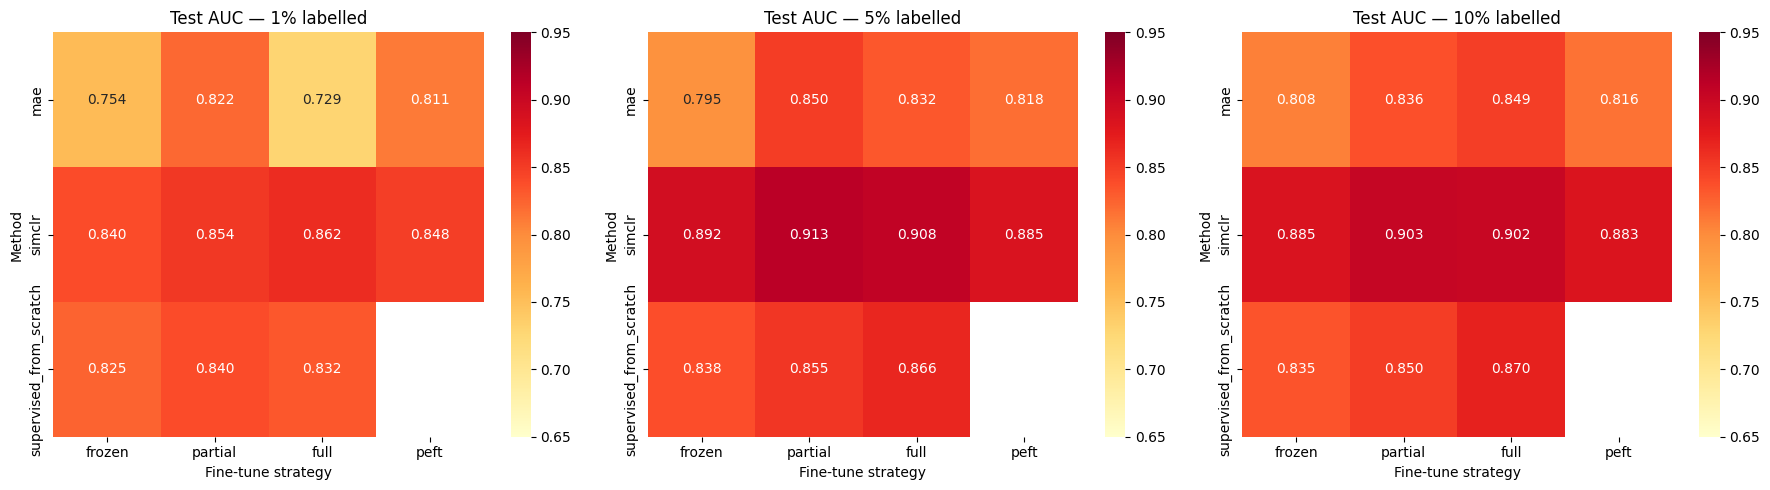

In [19]:
# AUC heatmap: method × strategy, 1 panel per label fraction
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Flatten summary's multi-index columns for simpler access
summary_flat = summary.copy()
summary_flat.columns = [
    '_'.join(filter(None, col)).strip('_') if isinstance(col, tuple) else col
    for col in summary_flat.columns.values
]
# Now columns are: method, strategy, label_fraction, test_auc_mean, test_auc_std, etc.

methods_arr = sorted(summary_flat['method'].unique())
strategies = ['frozen', 'partial', 'full', 'peft']
label_list = ['1%', '5%', '10%']

fig, axes = plt.subplots(1, len(label_list), figsize=(18, 5))
for ax, label in zip(axes, label_list):
    # Build methods × strategies matrix of mean AUC (NaN for skipped combos)
    matrix = np.full((len(methods_arr), len(strategies)), np.nan)
    for i, method in enumerate(methods_arr):
        for j, strat in enumerate(strategies):
            mask = (
                (summary_flat['method'] == method) &
                (summary_flat['strategy'] == strat) &
                (summary_flat['label_fraction'] == label)
            )
            row = summary_flat[mask]
            if len(row) > 0:
                matrix[i, j] = row['test_auc_mean'].values[0]

    sns.heatmap(
        matrix, annot=True, fmt='.3f',
        xticklabels=strategies, yticklabels=methods_arr,
        ax=ax, vmin=0.65, vmax=0.95, cmap='YlOrRd',
    )
    ax.set_title(f'Test AUC — {label} labelled')
    ax.set_xlabel('Fine-tune strategy')
    ax.set_ylabel('Method')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'auc_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

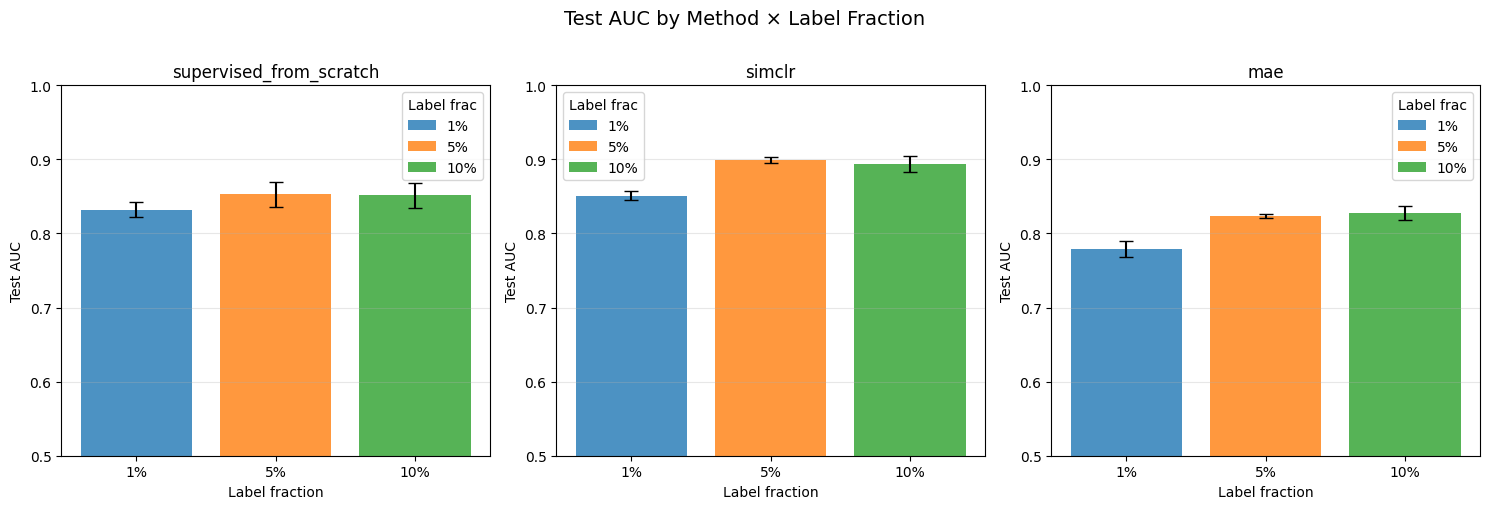

In [20]:
# Plot val AUC progression across label fractions for each method
# We use the first seed's history from run_single_experiment
# If you re-ran with multiple seeds, extract history from the saved dicts.

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, method in zip(axes, ['supervised_from_scratch', 'simclr', 'mae']):
    sub = results_df[results_df['method'] == method]
    for label in ['1%', '5%', '10%']:
        rows = sub[sub['label_fraction'] == label]
        means = rows.groupby('seed')['best_val_auc'].mean()
        aucs = rows.groupby('seed')['test_auc'].mean()
        ax.bar(label, aucs.mean(), yerr=aucs.std(), capsize=5,
               label=label, alpha=0.8)
    ax.set_title(method)
    ax.set_xlabel('Label fraction')
    ax.set_ylabel('Test AUC')
    ax.set_ylim(0.5, 1.0)
    ax.legend(title='Label frac')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Test AUC by Method × Label Fraction', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'auc_by_method_label.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
# Train best-config models ONCE, cache outputs for reuse
# by ROC, tSNE, Grad-CAM
from data import load_all_data, build_downstream_loaders, LABEL_FRACTIONS
from training import (
    build_simclr_classifier, build_supervised_scratch_classifier,
    build_mae_classifier, train_classifier,
    DEFAULT_EXPERIMENT_CONFIG, set_seed,
)
from evaluation import evaluate_model, extract_embeddings

# Configs to evaluate (10% labels, best strategy per method)
best_configs = [
    ('supervised_from_scratch', 'full',   None),
    ('simclr',                  'frozen', CHECKPOINT_DIR / 'simclr_encoder_tailored.pth'),
    ('mae',                     'frozen', CHECKPOINT_DIR / 'mae_encoder.pth'),
]

trained_models = {}

for method, strategy, ckpt_path in best_configs:
    print(f"\n>>> Training {method} / {strategy} ...")
    set_seed(42)

    if method == 'supervised_from_scratch':
        model = build_supervised_scratch_classifier()
    elif method == 'simclr':
        model = build_simclr_classifier(ckpt_path)
    elif method == 'mae':
        model = build_mae_classifier(ckpt_path)

    model, _, _, _ = train_classifier(
        model, train_loaders['10%'], val_loader,
        strategy=strategy, config=DEFAULT_EXPERIMENT_CONFIG,
    )

    # Evaluate once (gives y_true, y_prob, y_pred)
    metrics = evaluate_model(model, test_loader)
    # Embeddings once
    embeddings, emb_labels = extract_embeddings(model, test_loader, method)

    trained_models[method] = {
        'model': model,
        'strategy': strategy,
        'metrics': metrics,
        'embeddings': embeddings,
        'emb_labels': emb_labels,
    }
    print(f"  checked {method}: test AUC = {metrics['auc']:.4f}")

print(f"\n Cached {len(trained_models)} models — downstream cells will reuse.")


>>> Training supervised_from_scratch / full ...
epoch 1/15 | train_loss=0.4812 | val_auc=0.8869 | val_f1=0.8128
epoch 2/15 | train_loss=0.3879 | val_auc=0.8161 | val_f1=0.6898
epoch 3/15 | train_loss=0.2725 | val_auc=0.8746 | val_f1=0.7810
epoch 4/15 | train_loss=0.1278 | val_auc=0.8702 | val_f1=0.7535
Early stopping triggered.
  checked supervised_from_scratch: test AUC = 0.8832

>>> Training simclr / frozen ...
epoch 1/15 | train_loss=0.4678 | val_auc=0.8741 | val_f1=0.7527
epoch 2/15 | train_loss=0.3858 | val_auc=0.8936 | val_f1=0.8017
epoch 3/15 | train_loss=0.3620 | val_auc=0.8936 | val_f1=0.7912
epoch 4/15 | train_loss=0.3646 | val_auc=0.8917 | val_f1=0.7675
epoch 5/15 | train_loss=0.3599 | val_auc=0.8956 | val_f1=0.8037
epoch 6/15 | train_loss=0.3520 | val_auc=0.8953 | val_f1=0.7712
epoch 7/15 | train_loss=0.3422 | val_auc=0.8943 | val_f1=0.7448
epoch 8/15 | train_loss=0.3543 | val_auc=0.8897 | val_f1=0.7536
Early stopping triggered.
  checked simclr: test AUC = 0.8789

>>> Tra

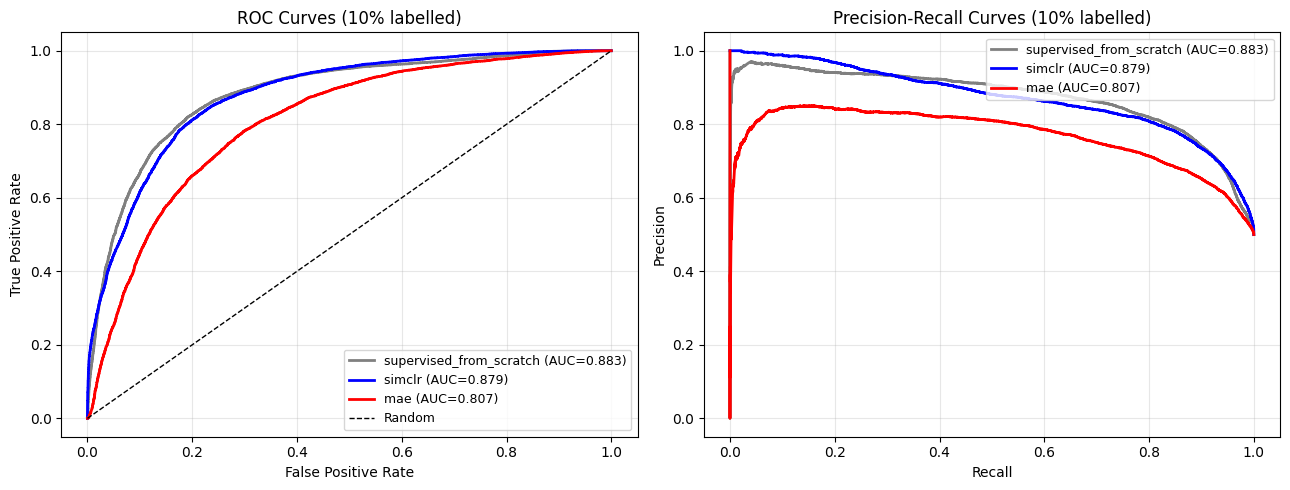

In [22]:
# ROC + Precision-Recall curves
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['gray', 'blue', 'red']

for (method, entry), color in zip(trained_models.items(), colors):
    m = entry['metrics']
    fpr, tpr, _ = roc_curve(m['y_true'], m['y_prob'])
    precision, recall, _ = precision_recall_curve(m['y_true'], m['y_prob'])

    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f"{method} (AUC={m['auc']:.3f})")
    axes[1].plot(recall, precision, color=color, lw=2,
                 label=f"{method} (AUC={m['auc']:.3f})")

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves (10% labelled)')
axes[0].legend(loc='lower right', fontsize=9); axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves (10% labelled)')
axes[1].legend(loc='upper right', fontsize=9); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

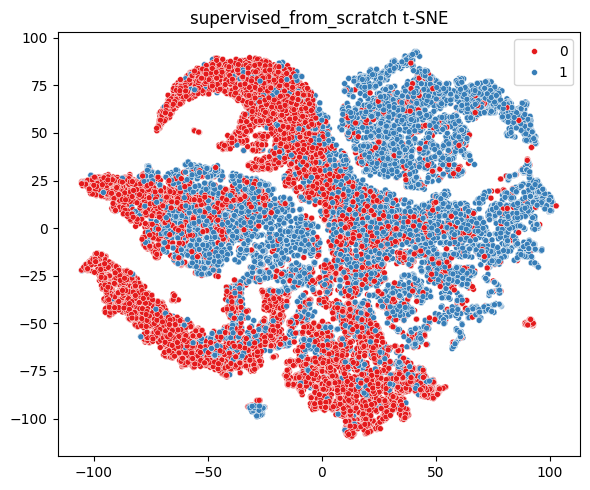

<Figure size 640x480 with 0 Axes>

t-SNE for supervised_from_scratch saved.


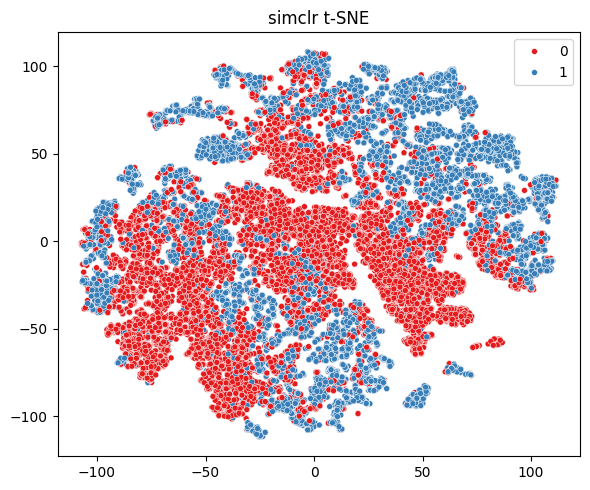

<Figure size 640x480 with 0 Axes>

t-SNE for simclr saved.


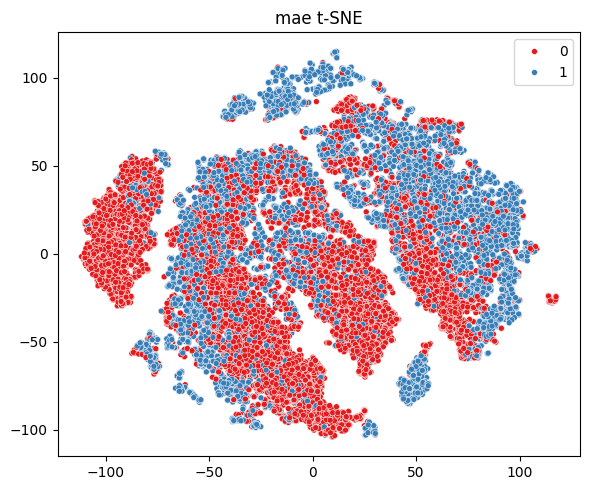

<Figure size 640x480 with 0 Axes>

t-SNE for mae saved.


In [23]:
# t-SNE plots
from evaluation import plot_tsne

for method, entry in trained_models.items():
    plot_tsne(entry['embeddings'], entry['emb_labels'], title=f'{method} t-SNE')
    plt.savefig(FIGURE_DIR / f'tsne_{method}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f't-SNE for {method} saved.')

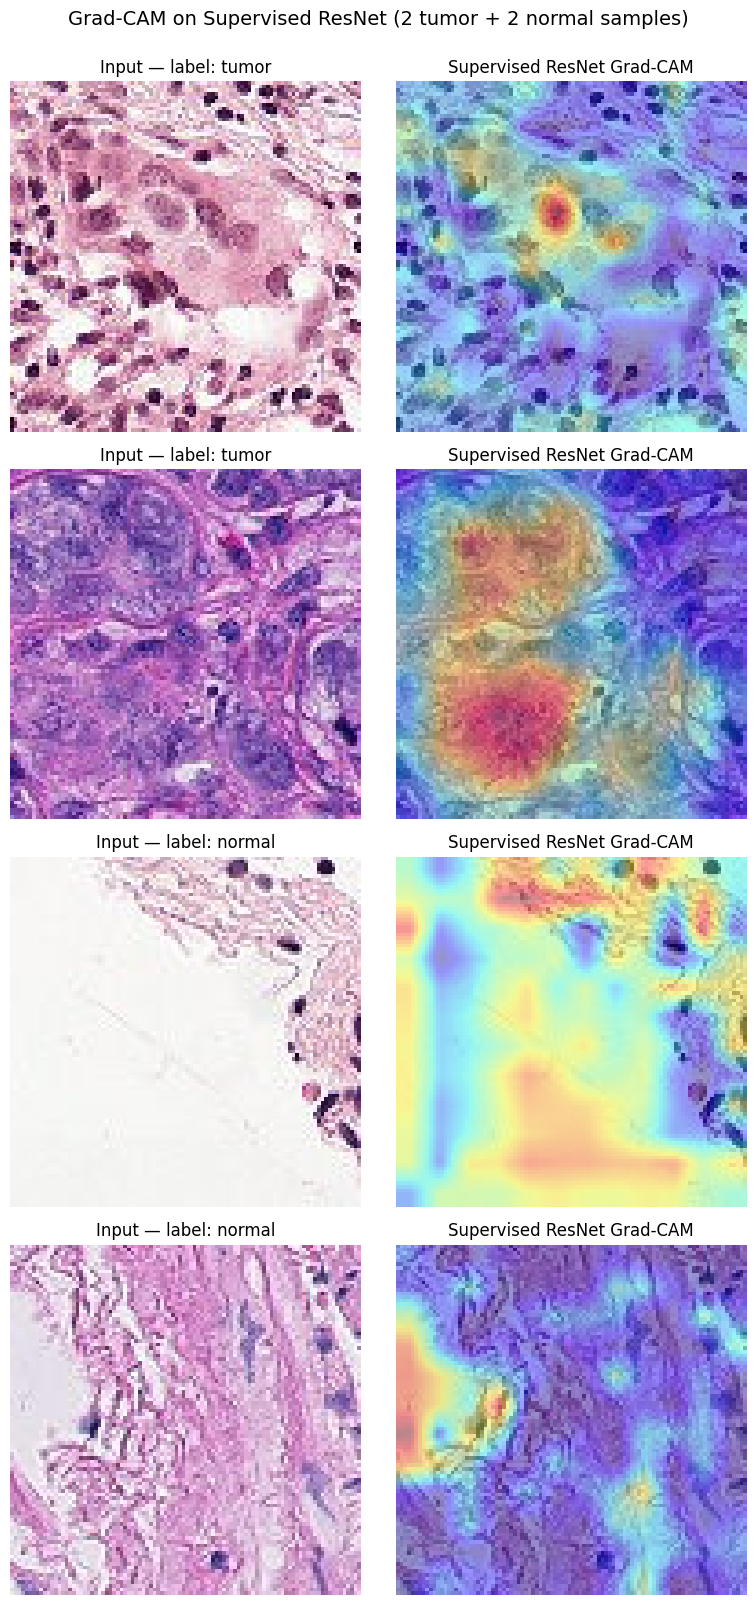

In [24]:
import torch
from evaluation import GradCAM
from data import make_classification_transform

model_sup = trained_models['supervised_from_scratch']['model']
device = 'cuda' if torch.cuda.is_available() else 'cpu'
transform = make_classification_transform(data.channel_mean, data.channel_std)

# Pick 4 test images (2 positive + 2 negative)
pos_idx = [i for i in range(200) if int(data.y_test[i]) == 1][:2]
neg_idx = [i for i in range(200) if int(data.y_test[i]) == 0][:2]
indices = pos_idx + neg_idx

fig, axes = plt.subplots(len(indices), 2, figsize=(8, 4 * len(indices)))

for row, idx in enumerate(indices):
    img = data.x_test[idx]
    label = int(data.y_test[idx])
    img_tensor = transform(img).unsqueeze(0).to(device)

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f'Input — label: {"tumor" if label == 1 else "normal"}')
    axes[row, 0].axis('off')

    cam_sup = GradCAM(model_sup.to(device), model_sup.encoder.layer4)
    heat_sup = cam_sup(img_tensor, class_idx=label)
    axes[row, 1].imshow(img)
    axes[row, 1].imshow(heat_sup, cmap='jet', alpha=0.4)
    axes[row, 1].set_title('Supervised ResNet Grad-CAM')
    axes[row, 1].axis('off')

plt.suptitle('Grad-CAM on Supervised ResNet (2 tumor + 2 normal samples)', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'gradcam_supervised.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
import torch
import torch.nn.functional as F
import numpy as np
from data import make_classification_transform

device = 'cuda' if torch.cuda.is_available() else 'cpu'
transform = make_classification_transform(data.channel_mean, data.channel_std)

class GradCAMFixed:
    """
    Grad-CAM with two fixes over the original:
    1. forward hook does NOT call .detach() so gradients can flow
    2. hooks are removed after each call to prevent accumulation
    """

    def __init__(self, model, target_module):
        self.model = model
        self.target_module = target_module

    def __call__(self, image_tensor, class_idx=None):
        gradients = None
        activations = None

        def forward_hook(module, inp, out):
            nonlocal activations
            activations = out
        def backward_hook(module, grad_input, grad_output):
            nonlocal gradients
            gradients = grad_output[0].detach()

        fh = self.target_module.register_forward_hook(forward_hook)
        bh = self.target_module.register_full_backward_hook(backward_hook)

        try:
            self.model.eval()
            image_tensor = image_tensor.requires_grad_(True)

            logits = self.model(image_tensor)
            if class_idx is None:
                class_idx = int(logits.argmax(dim=1).item())

            score = logits[:, class_idx]
            self.model.zero_grad()
            score.backward(retain_graph=True)

            if gradients is None:
                raise RuntimeError("Backward hook did not capture gradients")

            weights = gradients.mean(dim=(2, 3), keepdim=True)
            cam = (weights * activations.detach()).sum(dim=1, keepdim=True)
            cam = F.relu(cam)
            cam = F.interpolate(cam, size=image_tensor.shape[-2:],
                                mode='bilinear', align_corners=False)
            cam = cam.squeeze().cpu().numpy()
            cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
            return cam

        finally:
            fh.remove()
            bh.remove()


class AttentionRollout:
    """Attention rollout for MAEBinaryClassifier (ViT encoder)."""

    def __init__(self, model):
        self.model = model

    def __call__(self, image_tensor):
        attentions = []
        hooks = []

        def make_hook(storage):
            def hook_fn(module, inp, out):
                x = inp[0]
                B, N, C = x.shape
                qkv = module.qkv(x).reshape(B, N, 3, module.num_heads, C // module.num_heads)
                qkv = qkv.permute(2, 0, 3, 1, 4)
                q, k, _ = qkv.unbind(0)
                scale = (C // module.num_heads) ** -0.5
                attn = (q @ k.transpose(-2, -1)) * scale
                attn = attn.softmax(dim=-1).mean(dim=1).detach().cpu()
                storage.append(attn)
            return hook_fn

        # Register hooks
        for block in self.model.encoder.blocks:
            h = block.attn.register_forward_hook(make_hook(attentions))
            hooks.append(h)

        try:
            self.model.eval()
            with torch.no_grad():
                _ = self.model(image_tensor)

            # Rollout
            result = None
            for attn in attentions:
                attn = attn.squeeze(0)
                attn = 0.5 * attn + 0.5 * torch.eye(attn.size(0))
                attn = attn / attn.sum(dim=-1, keepdim=True)
                result = attn if result is None else (attn @ result)

            num_patches = self.model.encoder.num_patches
            cls_attn = result[0, 1:1 + num_patches]
            grid = int(num_patches ** 0.5)
            heatmap = cls_attn.reshape(grid, grid).numpy()

            heatmap = torch.tensor(heatmap).unsqueeze(0).unsqueeze(0).float()
            heatmap = F.interpolate(heatmap, size=image_tensor.shape[-2:],
                                    mode='bilinear', align_corners=False)
            heatmap = heatmap.squeeze().numpy()
            heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
            return heatmap

        finally:
            for h in hooks:
                h.remove()


def get_heatmap(method_name, model, image_tensor, class_idx):
    model = model.to(device)
    if method_name in ('supervised_from_scratch', 'simclr'):
        cam = GradCAMFixed(model, model.encoder.layer4)
        return cam(image_tensor, class_idx=class_idx)
    elif method_name in ('mae', 'mae_improved'):
        rollout = AttentionRollout(model)
        return rollout(image_tensor)
    else:
        raise ValueError(f"Unknown method: {method_name}")




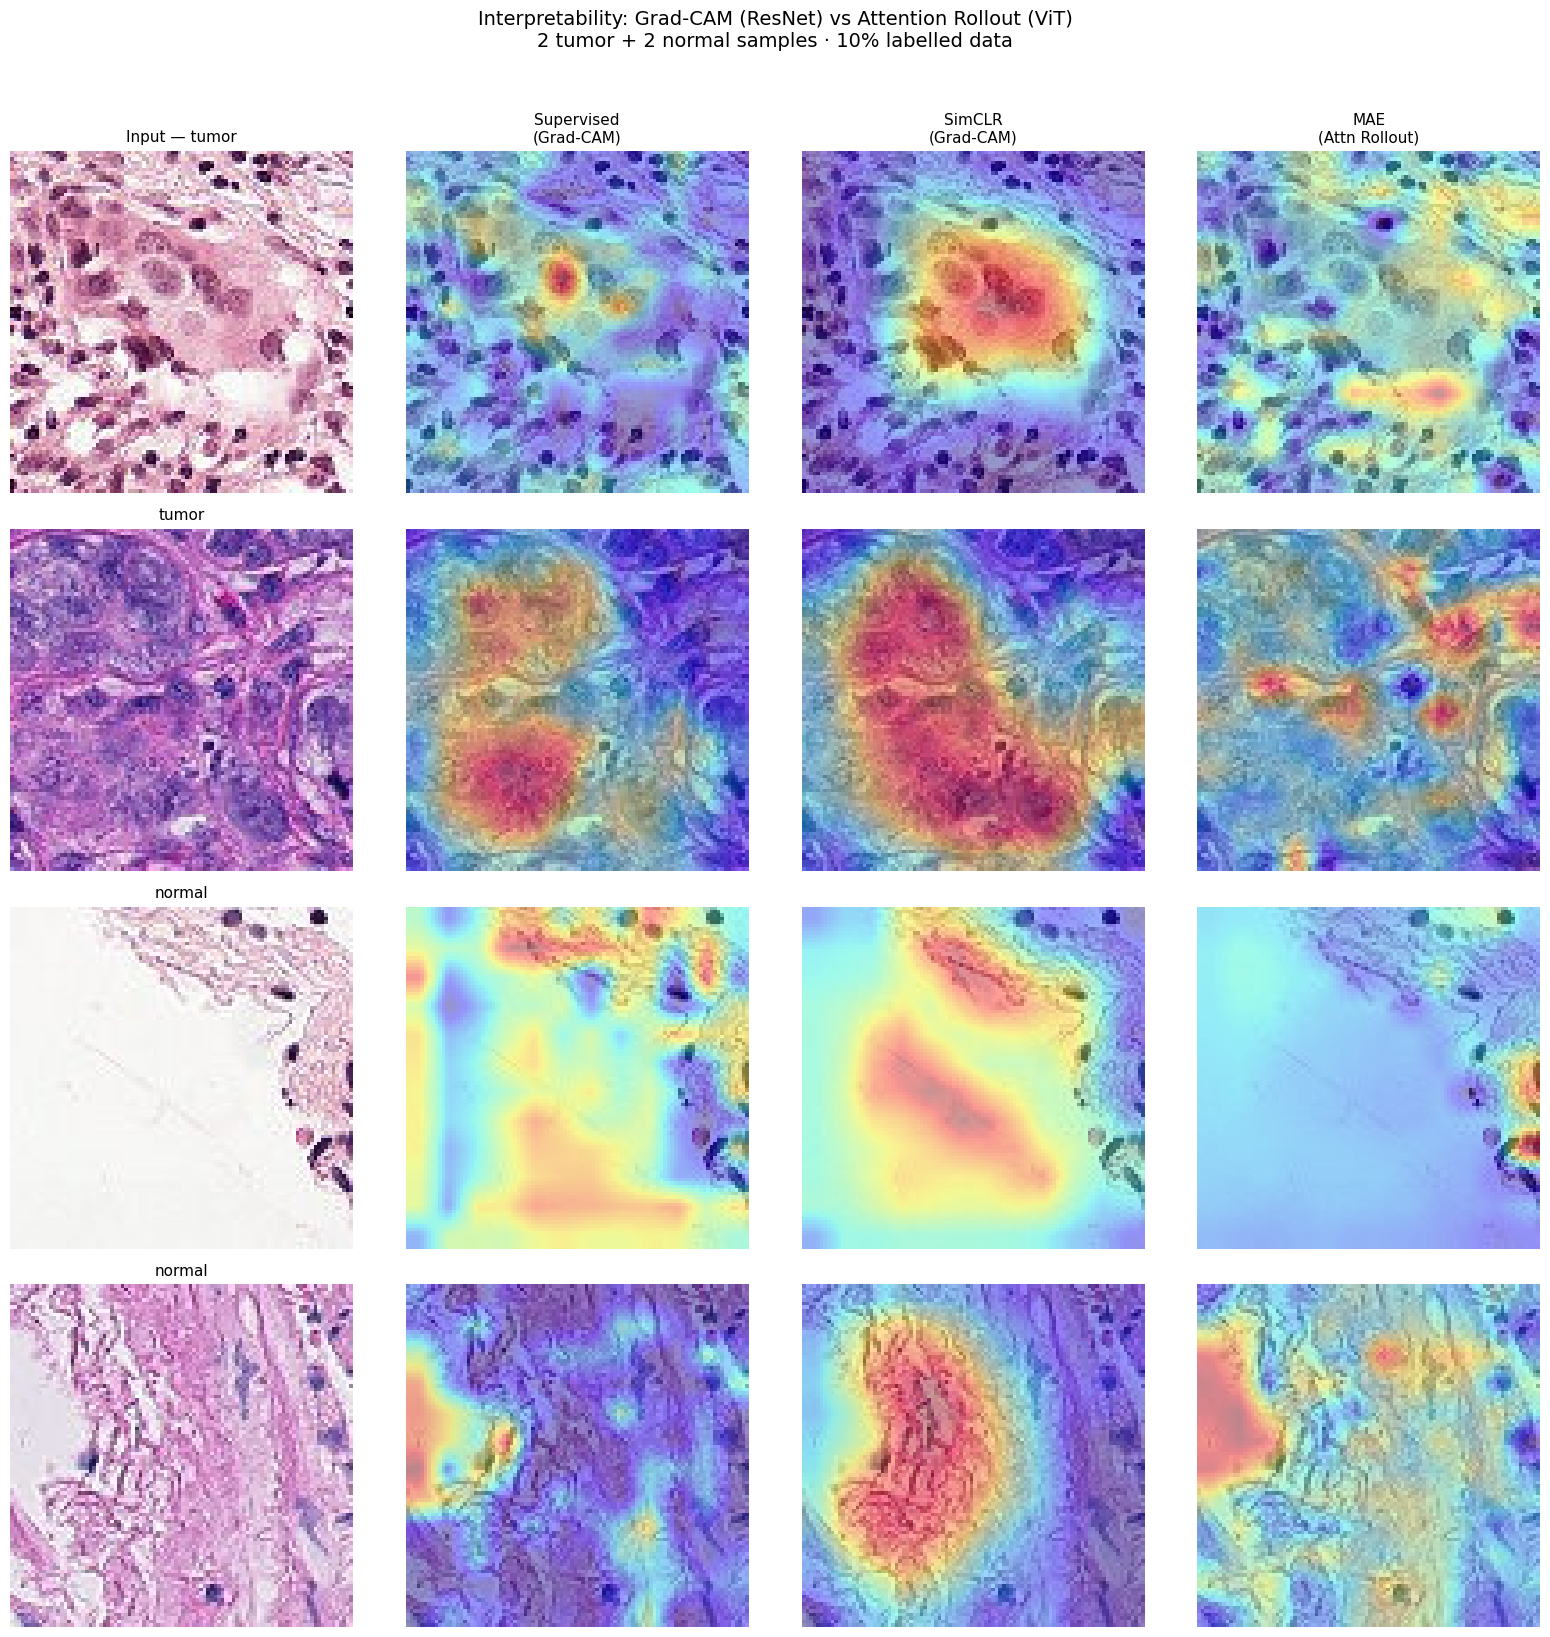

Saved -> figures/gradcam_all_methods.png


In [31]:
import matplotlib.pyplot as plt

methods_to_show = ['supervised_from_scratch', 'simclr', 'mae']
col_titles = [
    'Input Image',
    'Supervised\n(Grad-CAM)',
    'SimCLR\n(Grad-CAM)',
    'MAE\n(Attn Rollout)',
]

# 4 test images: 2 tumor + 2 normal
pos_idx = [i for i in range(200) if int(data.y_test[i]) == 1][:2]
neg_idx = [i for i in range(200) if int(data.y_test[i]) == 0][:2]
indices = pos_idx + neg_idx

n_rows = len(indices)
n_cols = 1 + len(methods_to_show)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))

for row, idx in enumerate(indices):
    img = data.x_test[idx]
    label = int(data.y_test[idx])
    img_tensor = transform(img).unsqueeze(0).to(device)
    label_str = 'tumor' if label == 1 else 'normal'

    # Column 0: original image
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f'Input — {label_str}' if row == 0 else label_str, fontsize=11)
    axes[row, 0].axis('off')

    # Columns 1-3: heatmap overlay per method
    for col, method in enumerate(methods_to_show, start=1):
        model_m = trained_models[method]['model']
        heatmap = get_heatmap(method, model_m, img_tensor, class_idx=label)
        axes[row, col].imshow(img)
        axes[row, col].imshow(heatmap, cmap='jet', alpha=0.4)
        if row == 0:
            axes[row, col].set_title(col_titles[col], fontsize=11)
        axes[row, col].axis('off')

plt.suptitle(
    'Interpretability: Grad-CAM (ResNet) vs Attention Rollout (ViT)\n'
    '2 tumor + 2 normal samples · 10% labelled data',
    fontsize=14, y=1.02,
)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'gradcam_all_methods.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved -> figures/gradcam_all_methods.png")

In [27]:
import os

print('Analysis Complete — Saved outputs')

print(f'\nResults:')
for f in sorted(os.listdir(RESULTS_DIR)):
    print(f'  {RESULTS_DIR}/{f}')

print(f'\nFigures:')
for f in sorted(os.listdir(FIGURE_DIR)):
    size = os.path.getsize(FIGURE_DIR / f) / 1e3
    print(f'  {FIGURE_DIR}/{f}  ({size:.0f} KB)')

print('\nFinished.')

Analysis Complete — Saved outputs

Results:
  /content/ST456_GroupProject/results/.gitkeep
  /content/ST456_GroupProject/results/report_table.csv
  /content/ST456_GroupProject/results/results_main.csv
  /content/ST456_GroupProject/results/results_seed42.csv
  /content/ST456_GroupProject/results/results_seed52.csv
  /content/ST456_GroupProject/results/results_seed62.csv
  /content/ST456_GroupProject/results/results_simclr_generic.csv

Figures:
  /content/figures/auc_by_method_label.png  (51 KB)
  /content/figures/auc_heatmap.png  (106 KB)
  /content/figures/gradcam_supervised.png  (380 KB)
  /content/figures/roc_pr_curves.png  (136 KB)
  /content/figures/tsne_mae.png  (5 KB)
  /content/figures/tsne_simclr.png  (5 KB)
  /content/figures/tsne_supervised_from_scratch.png  (5 KB)

Finished.


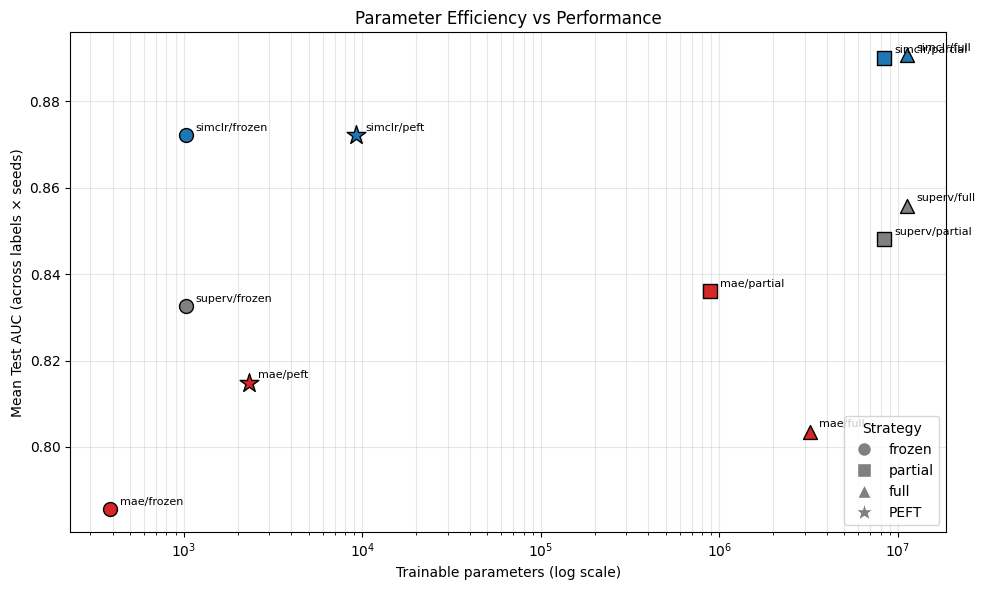


 Trainable Params Summary 
  mae                      frozen   ->          386 params | AUC = 0.7856
  mae                      full     ->    3,199,746 params | AUC = 0.8036
  mae                      partial  ->      890,498 params | AUC = 0.8361
  mae                      peft     ->        2,306 params | AUC = 0.8149
  simclr                   frozen   ->        1,026 params | AUC = 0.8722
  simclr                   full     ->   11,169,858 params | AUC = 0.8906
  simclr                   partial  ->    8,394,754 params | AUC = 0.8900
  simclr                   peft     ->        9,218 params | AUC = 0.8721
  supervised_from_scratch  frozen   ->        1,026 params | AUC = 0.8325
  supervised_from_scratch  full     ->   11,169,858 params | AUC = 0.8558
  supervised_from_scratch  partial  ->    8,394,754 params | AUC = 0.8481


In [28]:
# Pareto plot: trainable parameters vs test AUC
import matplotlib.pyplot as plt
from models import (
    count_trainable_params,
    build_simclr_classifier, build_mae_classifier, build_supervised_scratch_classifier,
    LoRAResNetClassifier, VPTMAEClassifier,
    configure_trainable_parameters,
)

# Count trainable params for each (method, strategy)
param_counts = {}

for method in ['supervised_from_scratch', 'simclr', 'mae']:
    for strategy in ['frozen', 'partial', 'full', 'peft']:
        if method == 'supervised_from_scratch' and strategy == 'peft':
            continue

        # Build a fresh classifier for each config
        if method == 'supervised_from_scratch':
            model = build_supervised_scratch_classifier()
        elif method == 'simclr':
            model = build_simclr_classifier(CHECKPOINT_DIR / 'simclr_encoder_tailored.pth')
        elif method == 'mae':
            model = build_mae_classifier(CHECKPOINT_DIR / 'mae_encoder.pth')

        # Apply strategy
        if strategy == 'peft':
            if method == 'simclr':
                model = LoRAResNetClassifier(model.encoder, feature_dim=512, rank=8)
            elif method == 'mae':
                model = VPTMAEClassifier(model.encoder, num_prompts=10, embed_dim=192)
        else:
            configure_trainable_parameters(model, strategy)

        param_counts[(method, strategy)] = count_trainable_params(model)

# Average test AUC across labels × seeds for each (method, strategy)
mean_auc = results_df.groupby(['method', 'strategy'])['test_auc'].mean().to_dict()

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

method_colors = {'supervised_from_scratch': 'gray', 'simclr': 'tab:blue', 'mae': 'tab:red'}
strategy_markers = {'frozen': 'o', 'partial': 's', 'full': '^', 'peft': '*'}

for (method, strategy), n_params in param_counts.items():
    auc = mean_auc.get((method, strategy), None)
    if auc is None:
        continue
    ax.scatter(
        n_params, auc,
        s=200 if strategy == 'peft' else 100,
        c=method_colors[method],
        marker=strategy_markers[strategy],
        edgecolors='black', linewidths=1,
        label=f"{method} / {strategy}",
        zorder=3 if strategy == 'peft' else 2,
    )
    ax.annotate(
        f"{method[:6]}/{strategy}",
        (n_params, auc),
        fontsize=8, xytext=(7, 3), textcoords='offset points',
    )

ax.set_xscale('log')
ax.set_xlabel('Trainable parameters (log scale)')
ax.set_ylabel('Mean Test AUC (across labels × seeds)')
ax.set_title('Parameter Efficiency vs Performance')
ax.grid(True, which='both', alpha=0.3)

# Legend by marker (strategy) only
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='frozen'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, label='partial'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=10, label='full'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='gray', markersize=14, label='PEFT'),
]
ax.legend(handles=legend_elems, title='Strategy', loc='lower right')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'pareto_params_vs_auc.png', dpi=150, bbox_inches='tight')
plt.show()

# A summary table
print("\n Trainable Params Summary ")
for (method, strategy), n_params in sorted(param_counts.items()):
    auc = mean_auc.get((method, strategy), float('nan'))
    print(f"  {method:<24} {strategy:<8} -> {n_params:>12,} params | AUC = {auc:.4f}")